In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import nltk, re, heapq
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.probability import FreqDist
from wordcloud import WordCloud

In [ ]:
# Run once only
nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')
nltk.download('vader_lexicon')

In [ ]:
# Define stop words
stop = set(stopwords.words("english"))

#### Set A

##### Q1
Consider any text paragraph. Preprocess the text to remove any special characters and 
digits. Generate the summary using extractive summarization process.

In [6]:
text = """The global shift toward renewable energy is no longer just an environmental goal; it has become an economic and geopolitical necessity.
As fossil fuel reserves continue to deplete and the impact of climate change becomes more severe,
nations are racing to modernize their power grids with sustainable alternatives. Solar and wind energy have emerged as the primary
frontrunners in this transition due to their rapidly falling costs and increasing efficiency. However, the intermittent nature of these
sources remains one of the most significant technical hurdles to overcome.
To address these challenges, engineers and scientists are focusing heavily on advanced energy storage technologies.
Large-scale lithium-ion battery arrays and emerging solid-state batteries are being deployed to store excess energy during peak
production hours for use during times of low generation. Furthermore, the integration of artificial intelligence into smart grids allows for
real-time monitoring and distribution of electricity, ensuring that supply meets demand with minimal waste.
Despite these advancements, the transition to a fully green economy faces political and infrastructural roadblocks.
Ultimately, the success of the renewable energy revolution will depend on a combination of innovative policy-making, massive infrastructure investment,
and a global commitment to reducing carbon footprints."""

In [ ]:
# Remove punctuation and extra whitespace
formatted = re.sub(r'\s+', ' ', re.sub(r'[^a-zA-Z ]', ' ', text))

In [ ]:
# Tokenize the text and calculate word frequencies
words = word_tokenize(formatted.lower())
wordfreq = {}
for w in words:
    if w not in stop:
        wordfreq[w] = wordfreq.get(w, 0) + 1

In [ ]:
# Normalize frequencies
max_freq = max(wordfreq.values())
wordfreq = {w: v / max_freq for w, v in wordfreq.items()}

In [10]:
sentences = sent_tokenize(text)
sent_scores = {}
for s in sentences:
    for w in word_tokenize(s.lower()):
        if w in wordfreq:
            sent_scores[s] = sent_scores.get(s, 0) + wordfreq[w]

In [11]:
top = sorted(heapq.nlargest(3, sent_scores, key=sent_scores.get),
             key=lambda x: text.find(x))

In [12]:
print("\nOriginal Text:\n", text)
print("\nSummary:\n", ' '.join(top))


Original Text:
 The global shift toward renewable energy is no longer just an environmental goal; it has become an economic and geopolitical necessity.
As fossil fuel reserves continue to deplete and the impact of climate change becomes more severe,
nations are racing to modernize their power grids with sustainable alternatives. Solar and wind energy have emerged as the primary
frontrunners in this transition due to their rapidly falling costs and increasing efficiency. However, the intermittent nature of these
sources remains one of the most significant technical hurdles to overcome.
To address these challenges, engineers and scientists are focusing heavily on advanced energy storage technologies.
Large-scale lithium-ion battery arrays and emerging solid-state batteries are being deployed to store excess energy during peak
production hours for use during times of low generation. Furthermore, the integration of artificial intelligence into smart grids allows for
real-time monitoring a

##### Q2
Consider the following review messages. Perform sentiment analysis on the messages. 

i. I purchased headphones online. I am very happy with the product. 

ii. I saw the movie yesterday. The animation was really good but the script was ok.

iii. I enjoy listening to music 

iv. I take a walk in the park everyday 

In [13]:
sia = SentimentIntensityAnalyzer()

In [14]:
reviews = [
    "I purchased headphones online. I am very happy with the product.",
    "I saw the movie yesterday. The animation was really good but the script was ok.",
    "I enjoy listening to music", 
    "I take a walk in the park everyday"
]

In [15]:
for review in reviews:
    score = sia.polarity_scores(review)['compound']
    sentiment = "Positive" if score >= 0.05 else "Negative" if score <= -0.05 else "Neutral"
    print(f"\nReview:    {review}")
    print(f"Score:     {score:.3f}")
    print(f"Sentiment: {sentiment}")


Review:    I purchased headphones online. I am very happy with the product.
Score:     0.612
Sentiment: Positive

Review:    I saw the movie yesterday. The animation was really good but the script was ok.
Score:     0.599
Sentiment: Positive

Review:    I enjoy listening to music
Score:     0.494
Sentiment: Positive

Review:    I take a walk in the park everyday
Score:     0.000
Sentiment: Neutral


##### Q3
Consider any text paragraph. Remove the stopwords. Tokenize the paragraph to extract 
words and sentences. Calculate the word frequency distribution and plot the frequencies. 
Plot the wordcloud of the text.

In [16]:
passage = """In the modern era of rapid technological advancement, the concept of intelligence is undergoing a profound transformation.
The rise of artificial intelligence has expanded our understanding of what it means to be smart.
The future of technology depends on the seamless integration of human intuition and digital intelligence.
Every day, new technology emerges, challenging our old perspectives. The intersection of human life and technology
is where the most significant innovations occur. Ultimately, the future is something we build with the intelligence
and technology available to us today."""

In [17]:
words = word_tokenize(passage.lower())
filtered = [w for w in words if w.isalpha() and w not in stop]

In [18]:
fdist = FreqDist(filtered)
print("\nTop 10 Words:\n", fdist.most_common(10))


Top 10 Words:
 [('intelligence', 4), ('technology', 4), ('future', 2), ('human', 2), ('modern', 1), ('era', 1), ('rapid', 1), ('technological', 1), ('advancement', 1), ('concept', 1)]


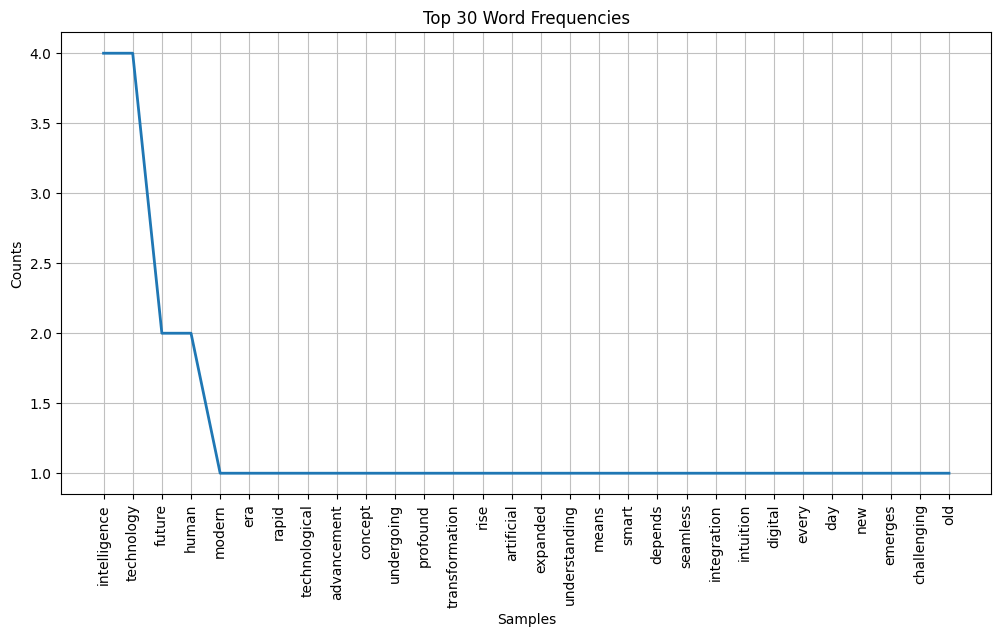

In [19]:
plt.figure(figsize=(12, 6))
fdist.plot(30, cumulative=False)
plt.title("Top 30 Word Frequencies")
plt.show()

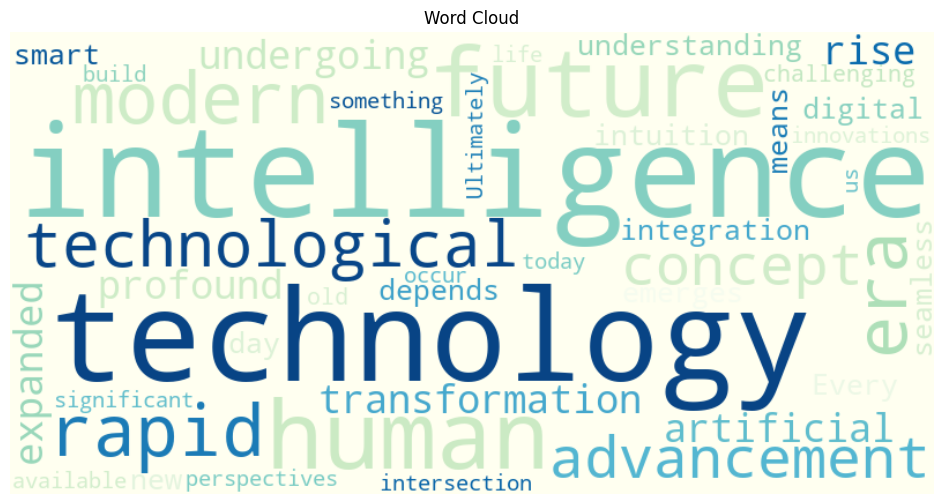

In [20]:
wc = WordCloud(width=800, height=400, background_color='ivory',
               colormap='GnBu', max_words=100).generate(passage)
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("Word Cloud")
plt.show()

##### Q4
Perform text analytics on WhatsApp data : 

Write a Python script for the following : 

i. First Export the WhatsApp chat of any group. Read the exported “.txt” file using open() and read() functions. 

ii. Tokenize the read data into sentences and print it. 

iii. Remove the stopwords from data and perform lemmatization. 

iv. Plot the wordcloud for the given data. 

In [22]:
with open("whatsapp_chat.txt", "r", encoding="utf-8") as f:
    chat = f.read()

In [23]:
words_chat = word_tokenize(chat.lower())
junk       = {'media', 'omitted', 'message', 'pm', 'am'}
names      = {'rahul', 'priya'}
stop_all   = stop.union(junk).union(names)
filtered_chat = [w for w in words_chat if w.isalpha() and w not in stop_all]
print(f"\nTotal words after filtering: {len(filtered_chat)}")


Total words after filtering: 42


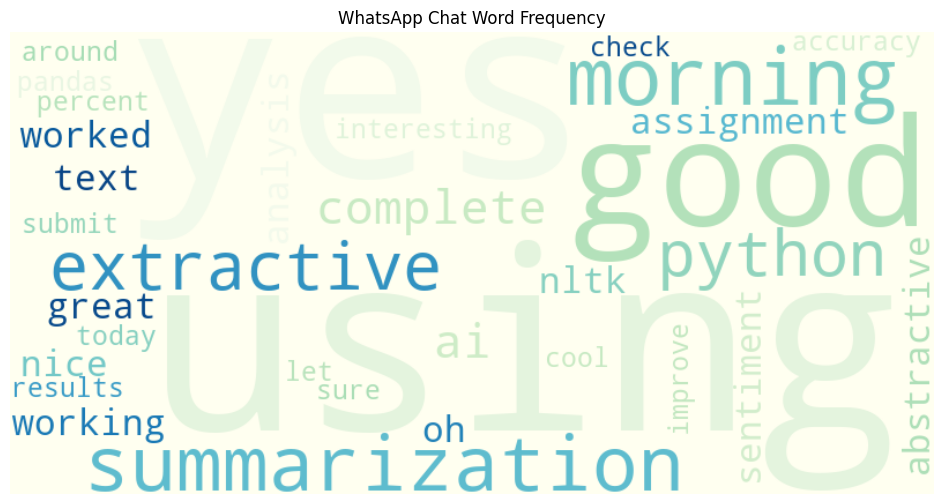

In [ ]:
wc = WordCloud(width=800, height=400, background_color='ivory',
               colormap='GnBu', max_words=150,
               collocations=False).generate(" ".join(filtered_chat))
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation='bilinear')
plt.axis('off')
plt.title("WhatsApp Chat Word Frequency")
plt.show()

#### Set B

##### Q1
Consider the following dataset : 
https://www.kaggle.com/datasets/prasertk/top-1000
instagram-influencers Write a Python script for the following  

i. Read the dataset and find the top 5 Instagram influencers from India. 

ii. Find the Instagram account having least number of followers. 

iii. Read the column “Category”, remove stopwords and plot the wordcloud to find the 
keywords which will imply that in which category maximum accounts are created. 

iv. Group the Instagram accounts category wise. 

v. Visualize the dataset and plot the relationship between Followers and Authentic engagement 
columns.

In [35]:
df = pd.read_csv("C:/Users/joel/Desktop/Shortened Programs/Data Analytics/docs/top_1000_instagrammers.csv")
print("\nDataset Info:"); print(df.info())


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 7 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   Name                  1000 non-null   object
 1   Rank                  1000 non-null   int64 
 2   Category              916 non-null    object
 3   Followers             1000 non-null   object
 4   Audience Country      986 non-null    object
 5   Authentic Engagement  1000 non-null   object
 6   Engagement Avg.       1000 non-null   object
dtypes: int64(1), object(6)
memory usage: 54.8+ KB
None


In [36]:
def parse_num(val):
    val = str(val).strip().replace(',', '')
    if val.endswith('M'): return float(val[:-1]) * 1_000_000
    elif val.endswith('K'): return float(val[:-1]) * 1_000
    return pd.to_numeric(val, errors='coerce')

In [37]:
df['Followers']       = df['Followers'].apply(parse_num)
df['Engagement Avg.'] = df['Engagement Avg.'].apply(parse_num)
df.dropna(subset=['Followers', 'Engagement Avg.'], inplace=True)

In [38]:
india_top5 = df[df['Audience Country'] == 'India'] \
               .sort_values('Followers', ascending=False).head(5)
print("\nTop 5 India Influencers:")
print(india_top5[['Name', 'Followers']])


Top 5 India Influencers:
            Name    Followers
28     instagram  528400000.0
0      cristiano  462900000.0
40       therock  327300000.0
23  justinbieber  245900000.0
12   virat.kohli  206900000.0


In [39]:
least_follower = df.nsmallest(1, 'Followers')
print("\nLeast Followers:")
print(least_follower[['Name', 'Followers']])


Least Followers:
                    Name  Followers
772  la_beaute_africaine  1600000.0


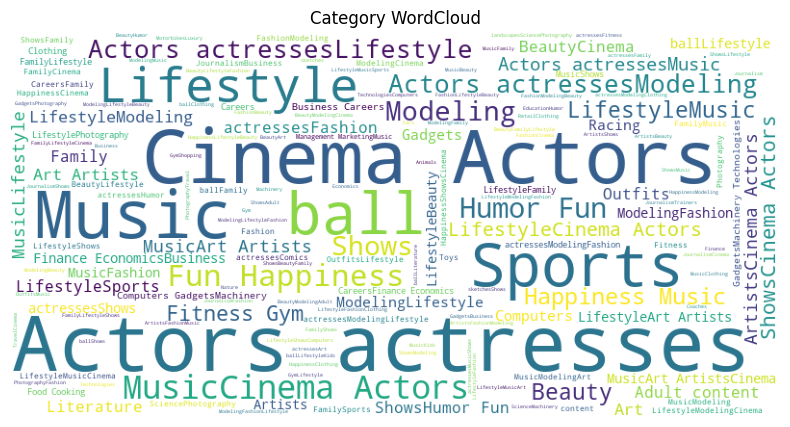

In [40]:
category_text = " ".join(df['Category'].dropna())
wc = WordCloud(width=800, height=400,
               background_color='white', stopwords=stop).generate(category_text)
plt.figure(figsize=(10, 5))
plt.imshow(wc); plt.axis('off')
plt.title("Category WordCloud"); plt.show()

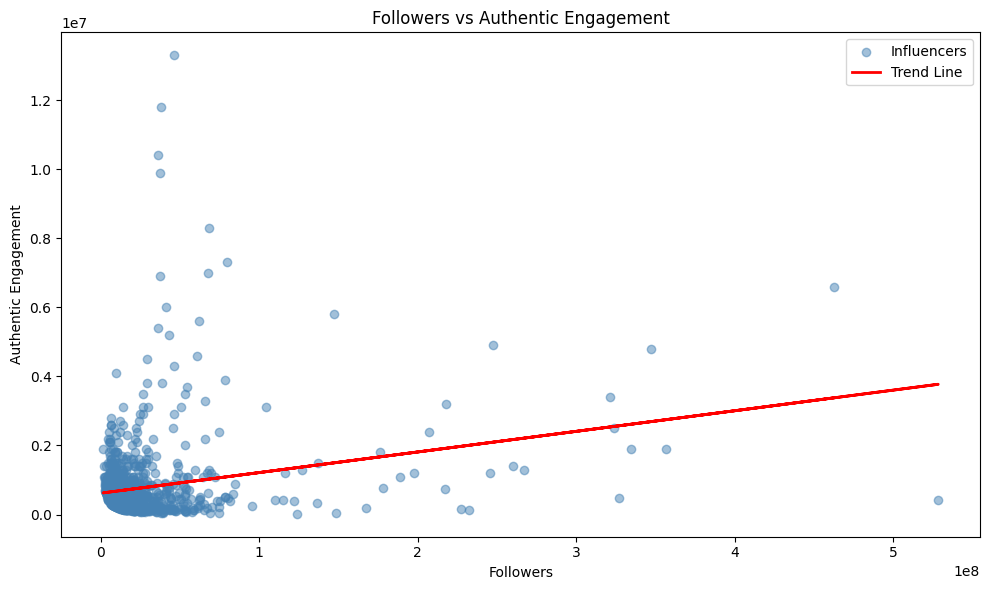

In [46]:
plt.figure(figsize=(10, 6))
plt.scatter(df['Followers'], df['Engagement Avg.'], alpha=0.5, color='steelblue', label='Influencers')

# Trend line
m, b = np.polyfit(df['Followers'], df['Engagement Avg.'], 1)
plt.plot(df['Followers'], m * df['Followers'] + b, color='red', linewidth=2, label='Trend Line')

plt.xlabel("Followers")
plt.ylabel("Authentic Engagement")
plt.title("Followers vs Authentic Engagement")
plt.legend()
plt.tight_layout()
plt.show()

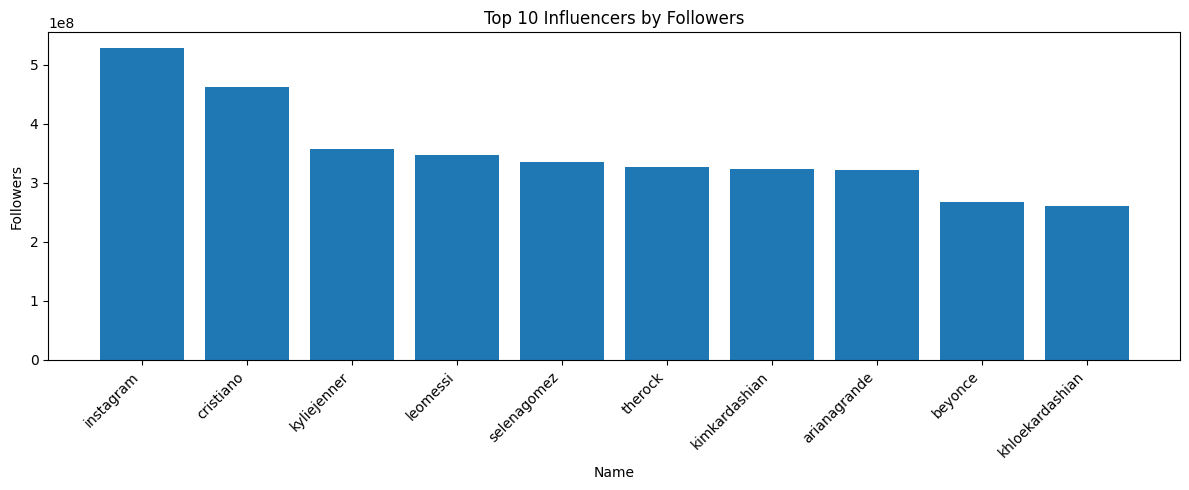

In [42]:
top10 = df.nlargest(10, 'Followers')
plt.figure(figsize=(12, 5))
plt.bar(top10['Name'], top10['Followers'])
plt.xticks(rotation=45, ha='right')
plt.title("Top 10 Influencers by Followers")
plt.xlabel("Name"); plt.ylabel("Followers")
plt.tight_layout(); plt.show()

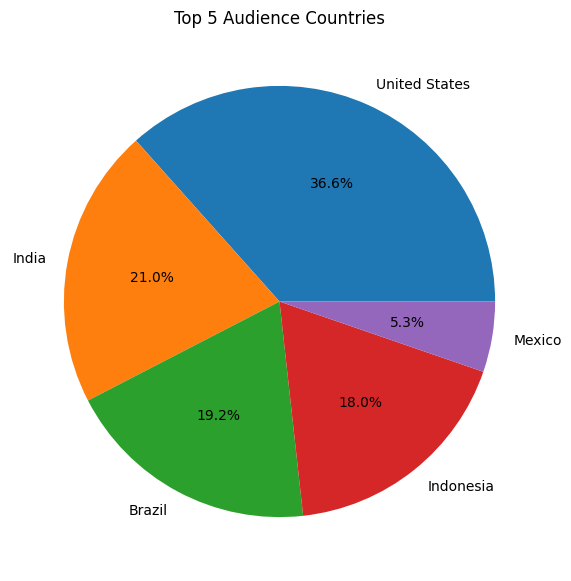

In [43]:
top_countries = df['Audience Country'].value_counts().head(5)
plt.figure(figsize=(7, 7))
plt.pie(top_countries, labels=top_countries.index, autopct='%1.1f%%')
plt.title("Top 5 Audience Countries")
plt.show()

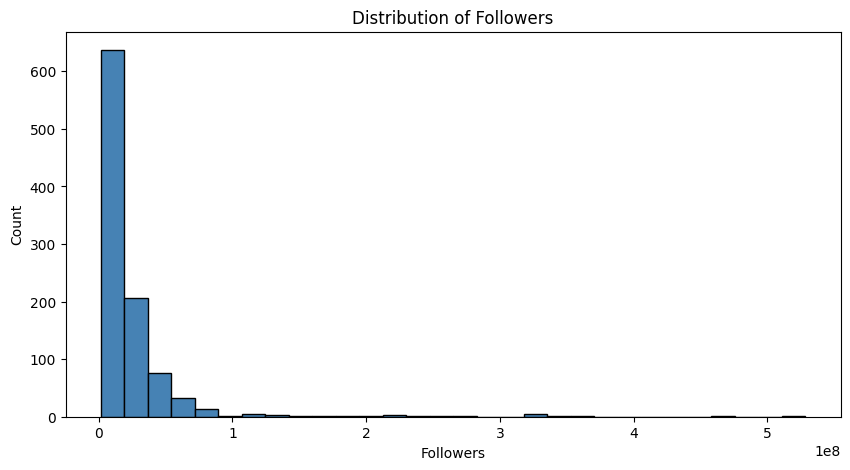

In [44]:
plt.figure(figsize=(10, 5))
plt.hist(df['Followers'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Followers")
plt.xlabel("Followers"); plt.ylabel("Count")
plt.show()

##### Q2
Consider the following dataset : 
https://www.kaggle.com/datasets/seungguini/youtube-comments-for
covid19-related- videos?select=covid_2021_1.csv 
Write a Python script for the following : 

i. Read the dataset and perform data cleaning operations on it. 

ii. Tokenize the comments in words.

iii. Perform sentiment analysis and find the percentage of positive, negative and neutral comments.
 


In [13]:
df = pd.read_csv("covid_2021_1.csv", encoding="latin1", on_bad_lines="skip")
df.columns = df.columns.str.replace("ï»¿", "", regex=False)
df.dropna(subset=["comment_text"], inplace=True)
df["comment_text"] = df["comment_text"].astype(str)
print("Shape:", df.shape)
print(df[["comment_text", "comment_date"]].head())

Shape: (2726, 14)
                                        comment_text          comment_date
0                        OMG ðð ððâ¤ï¸  2021-01-01T09:23:59Z
1                 I love my Indian Mumbai me welcome  2021-01-01T09:06:51Z
2                         What about indian vaccine?  2021-02-03T08:17:14Z
3            2:32 I like thatðð ððâ¤ï¸  2021-01-01T09:55:34Z
4  And all the rich companies that have profited ...  2021-01-01T13:17:56Z


In [14]:
stop = set(stopwords.words("english"))

all_words = []
for comment in df["comment_text"]:
    words = re.findall(r"\b[a-z]+\b", comment.lower())
    for w in words:
        if w not in stop and len(w) > 2:
            all_words.append(w)

print("Total tokens after filtering:", len(all_words))
print("Sample:", all_words[:10])

Total tokens after filtering: 25298
Sample: ['omg', 'love', 'indian', 'mumbai', 'welcome', 'indian', 'vaccine', 'like', 'rich', 'companies']


In [15]:
sia = SentimentIntensityAnalyzer()

sentiments = []
for comment in df["comment_text"]:
    score = sia.polarity_scores(comment)["compound"]
    if score >= 0.05:
        sentiments.append("Positive")
    elif score <= -0.05:
        sentiments.append("Negative")
    else:
        sentiments.append("Neutral")

df["sentiment"] = sentiments

counts = df["sentiment"].value_counts()
pct    = (counts / len(df) * 100).round(2)

print("Sentiment Counts:\n", counts)
print("\nPercentages:\n", pct)

Sentiment Counts:
 sentiment
Positive    1151
Neutral      979
Negative     596
Name: count, dtype: int64

Percentages:
 sentiment
Positive    42.22
Neutral     35.91
Negative    21.86
Name: count, dtype: float64


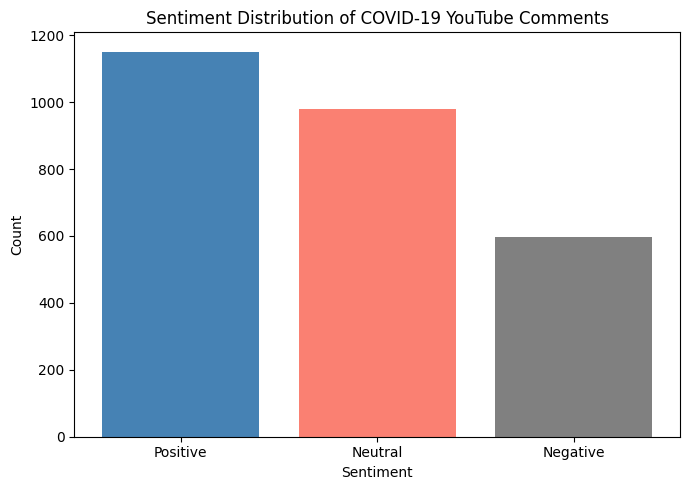

In [16]:
plt.figure(figsize=(7, 5))
plt.bar(counts.index, counts.values, color=["steelblue", "salmon", "gray"])
plt.title("Sentiment Distribution of COVID-19 YouTube Comments")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

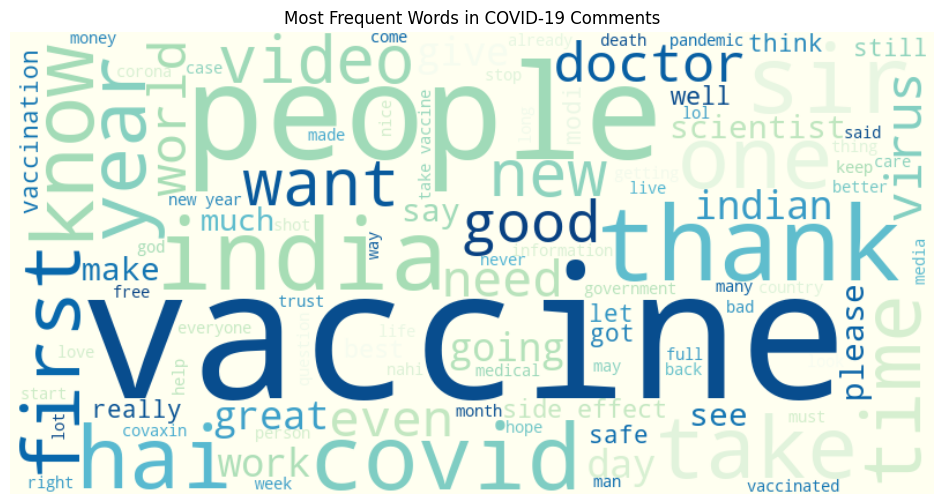

In [17]:
wc = WordCloud(width=800, height=400, background_color="ivory",
               colormap="GnBu", max_words=100).generate(" ".join(all_words))
plt.figure(figsize=(12, 6))
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.title("Most Frequent Words in COVID-19 Comments")
plt.show()

##### Q3
Consider the following dataset : 
https://www.kaggle.com/datasets/datasnaek/youtube
new?select=INvideos.csv Write a Python script for the following : 
i. Read the dataset and perform data cleaning operations on it. 

ii. Find the total views, total likes, total dislikes and comment count. 

iii. Find the least and topmost liked and commented videos. 

iv. Perform year wise statistics for views and plot the analyzed data. 

v. Plot the viewers who reacted on videos.

In [3]:
df = pd.read_csv("INvideos.csv", engine="python", on_bad_lines="skip")

In [4]:
df.dropna(inplace=True)

In [5]:
df['publish_time'] = pd.to_datetime(df['publish_time'])
df['year'] = df['publish_time'].dt.year

In [6]:
print("Shape:", df.shape)
print(df[["title", "views", "likes", "dislikes", "comment_count"]].head())

Shape: (688, 17)
                                               title    views  likes  \
0  Sharry Mann: Cute Munda ( Song Teaser) | Parmi...  1096327  33966   
1  पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...   590101    735   
2  Stylish Star Allu Arjun @ ChaySam Wedding Rece...   473988   2011   
3                     Eruma Saani | Tamil vs English  1242680  70353   
4  why Samantha became EMOTIONAL @ Samantha naga ...   464015    492   

   dislikes  comment_count  
0       798            882  
1       904              0  
2       243            149  
3      1624           2684  
4       293             66  


In [7]:
print("\nTotal Views:",   df['views'].sum())
print("Total Likes:",    df['likes'].sum())
print("Total Dislikes:", df['dislikes'].sum())
print("Total Comments:", df['comment_count'].sum())


Total Views: 545735840
Total Likes: 13215814
Total Dislikes: 663218
Total Comments: 1385373


In [8]:
print("\nMost Liked:");  print(df.nlargest(1,  'likes')[['title', 'likes']])
print("\nLeast Liked:"); print(df.nsmallest(1, 'likes')[['title', 'likes']])


Most Liked:
                                           title    likes
377  Ed Sheeran - Perfect (Official Music Video)  1721384

Least Liked:
                                                title  likes
34  Breaking News IT Raid - நடந்தது என்ன? சிக்கியத...      0


In [9]:
print("\nMost Commented:")
print(df.nlargest(1,  "comment_count")[["title", "comment_count"]])

print("\nLeast Commented:")
print(df.nsmallest(1, "comment_count")[["title", "comment_count"]])


Most Commented:
                                                 title  comment_count
545  Tiger Zinda Hai | Official Trailer | Salman Kh...         103907

Least Commented:
                                               title  comment_count
1  पीरियड्स के समय, पेट पर पति करता ऐसा, देखकर दं...              0


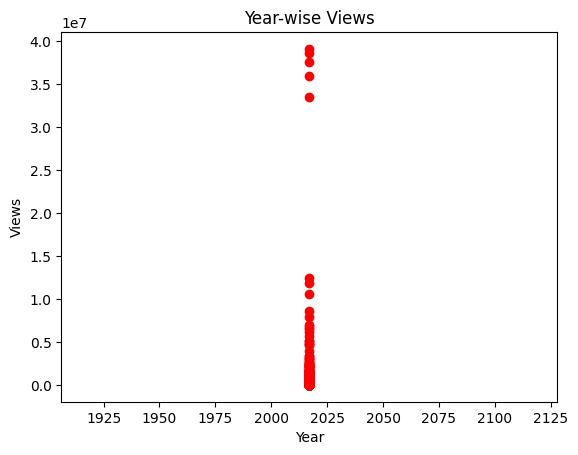

In [10]:
plt.scatter(df['year'], df['views'], color="red")
plt.xlabel("Year"); plt.ylabel("Views")
plt.title("Year-wise Views"); plt.show()

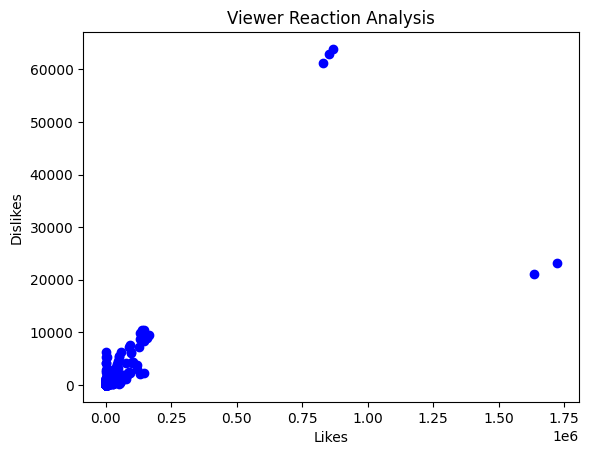

In [11]:
plt.scatter(df['likes'], df['dislikes'], color="blue")
plt.xlabel("Likes"); plt.ylabel("Dislikes")
plt.title("Viewer Reaction Analysis"); plt.show()

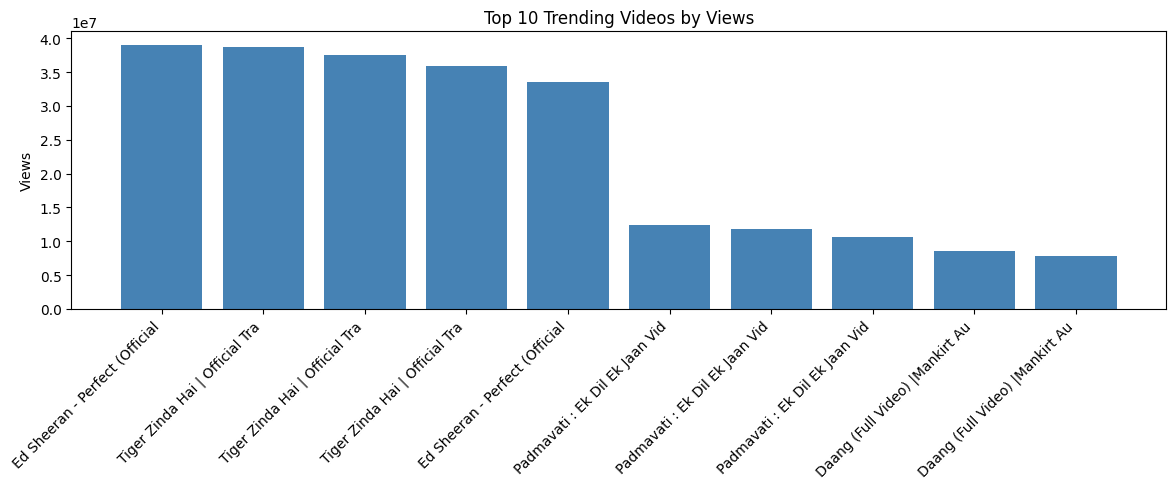

In [12]:
top10 = df.nlargest(10, "views")
plt.figure(figsize=(12, 5))
plt.bar(range(10), top10["views"], color="steelblue")
plt.xticks(range(10), top10["title"].str[:30], rotation=45, ha="right")
plt.title("Top 10 Trending Videos by Views")
plt.ylabel("Views")
plt.tight_layout()
plt.show()